In [4]:
!pip install -q "timecopilot" "utilsforecast" "matplotlib"
!pip install -q --force-reinstall --no-deps "numpy==1.26.4" "scipy==1.13.1"

print("Setup complete. Restarting the runtime to load clean binaries...")
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 22.5 MB/s eta 0:00:00
Setup complete. Restarting the runtime to load clean binaries...


{'status': 'ok', 'restart': True}

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

print("numpy:", np.__version__)
import scipy; print("scipy:", scipy.__version__)

try:
    import torch
    HAS_GPU = torch.cuda.is_available()
except Exception:
    HAS_GPU = False
print(f"GPU available: {HAS_GPU}")

df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/air_passengers.csv",
    parse_dates=["ds"],
)
df["unique_id"] = df["unique_id"].astype(str)

rng = np.random.default_rng(7)
dates = df["ds"].unique(); n = len(dates)
synth = pd.DataFrame({
    "unique_id": "Synthetic",
    "ds": dates,
    "y": (np.linspace(50, 250, n)
          + 40 * np.sin(2 * np.pi * np.arange(n) / 12)
          + rng.normal(0, 8, n)).round(2),
})
anomaly_idx = [30, 75, 120]
synth.loc[anomaly_idx, "y"] *= 2.2

panel = pd.concat([df[["unique_id", "ds", "y"]], synth], ignore_index=True)
print("\nPanel shape:", panel.shape)
print(panel.groupby("unique_id")["y"].agg(["count", "mean", "min", "max"]))

H, FREQ = 12, "MS"

In [ ]:
from timecopilot.forecaster import TimeCopilotForecaster
from timecopilot.models.stats import AutoARIMA, AutoETS, SeasonalNaive, Theta
from timecopilot.models.prophet import Prophet
from timecopilot.models.foundation.chronos import Chronos

chronos_repo = "amazon/chronos-bolt-small" if HAS_GPU else "amazon/chronos-bolt-tiny"
models = [
    SeasonalNaive(), AutoETS(), AutoARIMA(), Theta(), Prophet(),
    Chronos(repo_id=chronos_repo, alias="Chronos"),
]
if HAS_GPU:
    try:
        from timecopilot.models.foundation.timesfm import TimesFM
        models.append(TimesFM(repo_id="google/timesfm-2.0-500m-pytorch", alias="TimesFM"))
    except Exception as e:
        print("Skipping TimesFM:", e)

tcf = TimeCopilotForecaster(models=models)
print("\nModels:", [getattr(m, "alias", type(m).__name__) for m in models])

In [ ]:
print("\nRunning cross-validation (slow step: foundation weights download)...")
cv_df = tcf.cross_validation(df=panel, h=H, freq=FREQ, n_windows=3)
print(cv_df.head())

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape
eval_df = evaluate(cv_df.drop(columns=["cutoff"]), metrics=[mae, rmse, mape])
print("\n=== Per-series error (lower = better) ===")
print(eval_df.round(3))

model_cols = [c for c in eval_df.columns if c not in ("unique_id", "metric")]
leaderboard = (eval_df.groupby("metric")[model_cols].mean().T.sort_values("rmse"))
print("\n=== Leaderboard (mean across series) ===")
print(leaderboard.round(3))
best_model = leaderboard.index[0]
print(f"\n>>> Best model by mean RMSE: {best_model}")

In [ ]:
fcst_df = tcf.forecast(df=panel, h=H, freq=FREQ, level=[80, 95])
print("\nForecast columns:", list(fcst_df.columns))

def plot_series(uid, point_model=best_model):
    hist = panel[panel["unique_id"] == uid]; fc = fcst_df[fcst_df["unique_id"] == uid]
    plt.figure(figsize=(11, 4)); plt.plot(hist["ds"], hist["y"], color="black", label="history")
    if point_model in fc.columns:
        plt.plot(fc["ds"], fc[point_model], color="C0", label=f"{point_model} forecast")
        lo, hi = f"{point_model}-lo-95", f"{point_model}-hi-95"
        if lo in fc.columns and hi in fc.columns:
            plt.fill_between(fc["ds"], fc[lo], fc[hi], alpha=0.25, color="C0", label="95% interval")
    plt.title(f"{uid} — {point_model}"); plt.legend(); plt.tight_layout(); plt.show()

for uid in panel["unique_id"].unique():
    plot_series(uid)

numpy: 1.26.4
scipy: 1.13.1
GPU available: False

Panel shape: (288, 3)
               count        mean     min     max
unique_id                                       
AirPassengers    144  280.298611  104.00  622.00
Synthetic        144  152.834903   17.62  480.81

Models: ['SeasonalNaive', 'AutoETS', 'AutoARIMA', 'Theta', 'Prophet', 'Chronos']

Running cross-validation (slow step: foundation weights download)...


3it [00:01,  1.98it/s]
3it [00:02,  1.01it/s]
3it [00:15,  5.02s/it]
3it [00:00,  6.41it/s]
0it [00:00, ?it/s]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
1it [00:00,  2.94it/s]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
2it [00:00,  3.08it/s]INFO:prophet:Disabling weekly seasonal

       unique_id         ds     cutoff      y  SeasonalNaive     AutoETS   AutoARIMA       Theta     Prophet     Chronos
0  AirPassengers 1958-01-01 1957-12-01  340.0          315.0  343.818500  345.972083  341.193039  371.659726  353.694916
1  AirPassengers 1958-02-01 1957-12-01  318.0          301.0  338.841500  331.735846  337.305143  370.479285  364.655670
2  AirPassengers 1958-03-01 1957-12-01  362.0          356.0  391.522105  386.793257  387.830649  402.493200  376.566711
3  AirPassengers 1958-04-01 1957-12-01  348.0          348.0  377.017455  378.779305  372.340533  397.985856  383.137817
4  AirPassengers 1958-05-01 1957-12-01  363.0          355.0  370.021231  385.782695  371.599509  400.675108  395.576324

=== Per-series error (lower = better) ===
       unique_id metric  SeasonalNaive  AutoETS  AutoARIMA   Theta  Prophet  Chronos
0  AirPassengers    mae         35.917   32.822     27.824  29.412   33.508   28.607
1      Synthetic    mae         31.983   17.373     24.006  4


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
100%|██████████| 1/1 [00:00<00:00, 31.26it/s]



Forecast columns: ['unique_id', 'ds', 'SeasonalNaive', 'SeasonalNaive-lo-80', 'SeasonalNaive-lo-95', 'SeasonalNaive-hi-80', 'SeasonalNaive-hi-95', 'AutoETS', 'AutoETS-lo-95', 'AutoETS-lo-80', 'AutoETS-hi-80', 'AutoETS-hi-95', 'AutoARIMA', 'AutoARIMA-lo-95', 'AutoARIMA-lo-80', 'AutoARIMA-hi-80', 'AutoARIMA-hi-95', 'Theta', 'Theta-lo-80', 'Theta-hi-80', 'Theta-lo-95', 'Theta-hi-95', 'Prophet', 'Prophet-lo-80', 'Prophet-hi-80', 'Prophet-lo-95', 'Prophet-hi-95', 'Chronos', 'Chronos-lo-80', 'Chronos-hi-80', 'Chronos-lo-95', 'Chronos-hi-95']


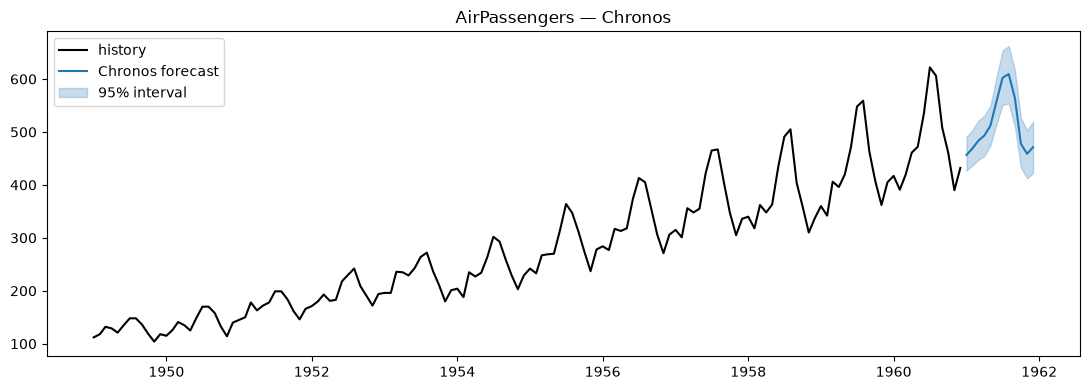

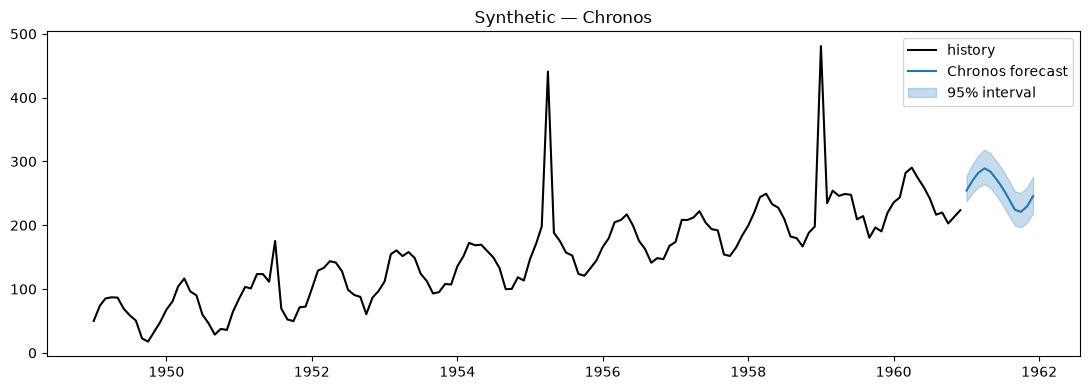


Running anomaly detection...


11it [00:01,  5.52it/s]
11it [00:03,  2.93it/s]
11it [00:23,  2.11s/it]
11it [00:01,  6.84it/s]
0it [00:00, ?it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
1it [00:00,  3.11it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p

Flagged points (>=1 model): 45
    unique_id         ds       y  SeasonalNaive-anomaly  AutoETS-anomaly  AutoARIMA-anomaly  Theta-anomaly  Prophet-anomaly  Chronos-anomaly
AirPassengers 1951-05-01 172.000                   True            False              False          False            False            False
AirPassengers 1951-07-01 199.000                  False            False               True          False            False            False
AirPassengers 1951-08-01 199.000                  False            False               True          False            False            False
    Synthetic 1951-07-01 175.384                  False             True               True          False             True             True
AirPassengers 1952-08-01 242.000                  False            False              False           True            False            False
AirPassengers 1953-04-01 235.000                   True            False              False          False            False

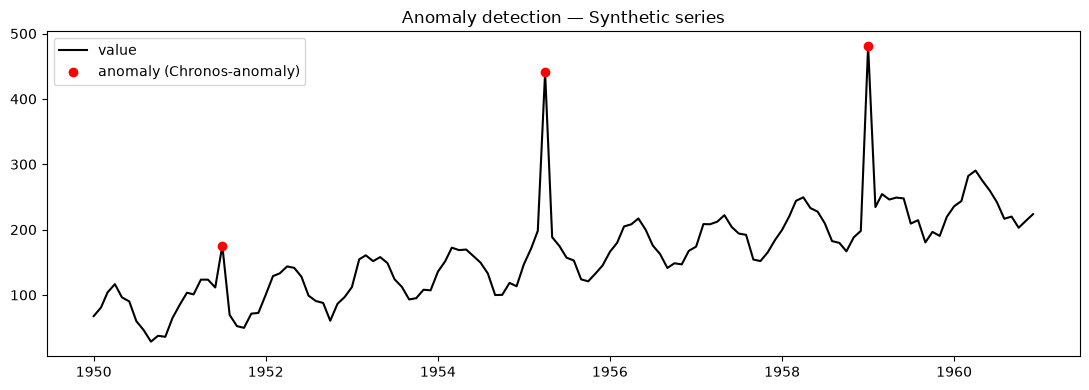


[Agent section skipped] No LLM key. Everything above ran key-free.

Done. ✅


In [2]:
print("\nRunning anomaly detection...")
anomalies_df = tcf.detect_anomalies(df=panel, h=H, freq=FREQ, level=99)
anom_cols = [c for c in anomalies_df.columns if c.endswith("-anomaly")]
if anom_cols:
    flagged = anomalies_df[anomalies_df[anom_cols].any(axis=1)]
    print(f"Flagged points (>=1 model): {len(flagged)}")
    print(flagged[["unique_id", "ds", "y"] + anom_cols].head(20).to_string(index=False))
    col = f"{best_model}-anomaly"
    if col not in anomalies_df.columns: col = anom_cols[0]
    sub = anomalies_df[anomalies_df["unique_id"] == "Synthetic"]
    pts = sub[sub[col] == True]
    plt.figure(figsize=(11, 4)); plt.plot(sub["ds"], sub["y"], color="black", label="value")
    plt.scatter(pts["ds"], pts["y"], color="red", zorder=5, label=f"anomaly ({col})")
    plt.title("Anomaly detection — Synthetic series"); plt.legend(); plt.tight_layout(); plt.show()
else:
    print(anomalies_df.head())

from timecopilot import TimeCopilot
if os.environ.get("OPENAI_API_KEY") or os.environ.get("ANTHROPIC_API_KEY"):
    llm = "openai:gpt-4o" if os.environ.get("OPENAI_API_KEY") else "anthropic:claude-sonnet-4-5"
    tc = TimeCopilot(llm=llm, retries=3)
    single = panel[panel["unique_id"] == "AirPassengers"]
    result = tc.forecast(df=single, freq=FREQ, h=H,
                         query="Total air passengers expected over the next 12 months, and which months peak?")
    out = result.output
    print("\n=== AGENT REPORT ===")
    print("Selected model:", out.selected_model)
    print("Beats SeasonalNaive:", out.is_better_than_seasonal_naive)
    print("Why:", out.reason_for_selection)
    print("Answer:", out.user_query_response)
    print(result.fcst_df.head())
else:
    print("\n[Agent section skipped] No LLM key. Everything above ran key-free.")

print("\nDone. ✅")